# **Project Name** – Netflix Movies and TV Shows Clustering (EDA)


##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project performs an exploratory data analysis (EDA) of Netflix’s catalog of movies and TV shows, using the dataset “NETFLIX MOVIES AND TV SHOWS CLUSTERING,” to uncover patterns in content type, geography, genre, ratings, and duration. The goal is to understand the structure and composition of the catalog and to prepare a clean, feature-rich dataset suitable for downstream clustering and recommendation use cases.

The dataset contains 7,787 titles and 12 variables: show_id, type (Movie or TV Show), title, director, cast, country, date_added, release_year, rating, duration, listed_in (genres), and description. The analysis followed a structured flow: knowing the data, understanding the variables, data wrangling, and visualization (following Univariate, Bivariate, and Multivariate analysis). Duplicate and missing-value checks showed no duplicate rows; missing values were present in director (about 30%), cast (about 9%), country (about 6%), and smaller shares in date_added and rating. These were handled in the wrangling step so that no rows were dropped unnecessarily for EDA.

In the data wrangling phase, missing values in director, cast, country, and rating were filled with “Unknown.” The date_added column was parsed into datetime, and a year_added variable was created for trend analysis. Because duration is stored as text (e.g. “93 min” for movies and “4 Seasons” for TV shows), two numeric features were derived: duration_min for movies and duration_seasons for TV shows. In addition, primary_genre and primary_country were created by taking the first value from the comma-separated listed_in and country fields, simplifying later visualizations and clustering.

The visualization section includes more than 20 charts. Univariate analysis covered the distribution of type (Movie vs TV Show), release year, content rating, movie duration, top countries, top genres, and TV show season counts. Bivariate analysis examined relationships such as type versus rating, content added per year, content added by year and type, release year versus movie duration (scatter), and top countries by type. Multivariate views included stacked and grouped charts (e.g. top genres by type), a correlation heatmap of numeric variables, and a pair plot. Additional charts on release year by type, ratings over time, movie duration by rating, country-by-type heatmap, and genre trends over years provided further insight into how the catalog is structured and how it has evolved.

Main findings from the EDA are that movies significantly outnumber TV shows; the catalog is skewed toward recent content (roughly 2015–2020); TV-MA and TV-14 dominate the rating mix; the United States leads by content count, followed by India and the United Kingdom; and International Movies, Dramas, and Comedies are the most common genres. Content additions grew strongly until around 2019–2020. Movie runtimes cluster around 90–120 minutes, and most TV shows have one or two seasons. These patterns have direct business relevance: they inform content strategy (balance of movies vs TV, genre mix), regional licensing and local production, age-based targeting and parental controls, and the design of recommendation and discovery features.

The cleaned and engineered dataset, with type, primary_country, primary_genre, rating, duration_min, duration_seasons, year_added, and release_year, is ready for clustering (e.g. K-means or hierarchical) to segment titles into content groups. Such segments can support similar-title recommendations, inventory planning, and data-driven content acquisition. This project thus delivers both a clear picture of the current Netflix catalog and a foundation for subsequent machine learning and clustering work.

# **GitHub Link -**

Provide your GitHub repository link here (e.g. the repo containing this notebook and the dataset, or a readme with instructions to run it).

# **Problem Statement**


Netflix offers a large and diverse catalog of movies and TV shows across regions, genres, and release periods. To make the most of this catalog—for content strategy, acquisition, recommendations, and user experience—the business needs a clear, data-driven view of **what is in the library**, **how it has changed over time**, and **how key dimensions relate to each other**.

The **problem** is to take the available catalog dataset (titles with type, director, cast, country, date added, release year, rating, duration, genre, and description) and, through exploratory data analysis (EDA), **answer questions** such as: How is content split between movies and TV shows? Which countries and genres dominate? How do ratings and runtimes distribute? How has the catalog grown year over year, and does that growth differ by type, genre, or region? Are there notable relationships between variables (e.g. release year and duration, or type and rating) that should inform segmentation or modeling?

The outcome of this analysis should **support downstream work** (e.g. clustering titles into content groups for "similar titles" or strategy segments) and **inform business decisions** on content mix, regional focus, age targeting, and product features such as filters and recommendations. Thus the problem is both **analytical** (understand the data) and **strategic** (turn that understanding into actionable insights for the business).

#### **Define Your Business Objective?**

The **business objective** is to use exploratory data analysis to **uncover and quantify patterns** in Netflix’s catalog so that the organization can:

1. **Understand the current state** of the library—how content is distributed across **type** (movie vs. TV show), **geography** (country), **genre**, **content rating**, and **duration**—and how the catalog has **evolved over time** (e.g. titles added per year, recency of releases).

2. **Identify relationships** between these dimensions (e.g. which genres are more common for movies vs. TV shows, which countries have a more balanced mix, how runtimes and ratings relate to type and genre) so that strategy and product decisions can be grounded in evidence rather than intuition.

3. **Prepare a clean, structured dataset** and a set of **interpretable insights** that can feed into **clustering** (e.g. grouping similar titles for “More like this” or content segments) and **recommendation strategy** (e.g. which attributes to use for similarity, how to balance catalog in different regions or for different audiences).

4. **Support strategic choices** on content acquisition, original production, regional licensing, age-based targeting (e.g. family vs. mature), and product features (e.g. filters, browse categories) by providing a clear, chart-backed picture of the catalog.

In short, the business objective is to **turn raw catalog data into actionable insight** that improves content strategy, user discovery, and readiness for follow-on analytics such as clustering and recommendation models.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

In [4]:
# Display shape
df.shape

(7787, 12)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

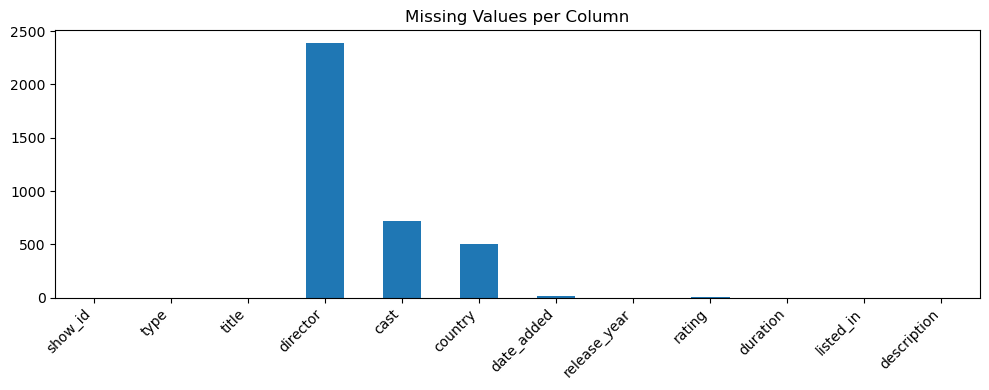

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 4))
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

After exploring the dataset, we have a clear picture of its structure and quality:

**Scale and scope:** The dataset contains **7,787 rows** and **12 columns**, with each row representing a single Netflix title (movie or TV show). The columns cover identifiers, content type, creative credits (director, cast), geography (country), temporal information (date_added, release_year), content classification (rating, duration, listed_in), and a short description.

**Data quality:** There are **no duplicate rows**; every record is unique. This is important for clustering and aggregation, as we do not need to deduplicate. **Missing values** are present in several columns: director has the highest share (around 30% missing), followed by cast (about 9%), country (about 6%), and smaller proportions in date_added and rating. These gaps are common in catalog data (e.g. documentaries or older titles may lack director or cast) and are acceptable for EDA; we address them in the wrangling step so that visualizations and analyses do not drop large portions of the data.

**Variable types:** The dataset mixes **object (string)** columns—such as title, director, cast, country, rating, duration, listed_in, and description—with an **integer** column (release_year). The *duration* column is stored as text (e.g. "93 min" for movies and "4 Seasons" for TV shows), so we will need to parse it to obtain numeric duration for movies and season counts for TV shows in later analysis and clustering.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [10]:
# Dataset Describe (numerical columns)
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


### Variables Description

Below is a concise description of each variable in the dataset. Understanding these definitions ensures that we interpret the analyses and visualizations correctly and use the right fields for clustering and recommendations.

| Variable    | Description |
|------------|-------------|
| show_id    | Unique identifier for each title; useful for joining or deduplication. |
| type       | Content format: either "Movie" or "TV Show"; central for segmenting the catalog. |
| title      | Display name of the title. |
| director   | Name(s) of the director(s); may be missing for some titles (e.g. documentaries, anthologies). |
| cast       | Main cast members; comma-separated; may be missing. |
| country    | Production country or countries; comma-separated when multiple. |
| date_added | Date the title was added to Netflix; used for trend and recency analysis. |
| release_year | Original release or first-air year; the only numeric column in the raw data. |
| rating     | Content rating (e.g. TV-MA, TV-14, PG-13, R); guides age-appropriateness and filters. |
| duration   | Length as text: minutes for movies (e.g. "93 min") or number of seasons for TV shows (e.g. "4 Seasons"). |
| listed_in  | Genre(s) or categories; comma-separated; used for genre and recommendation analysis. |
| description| Short plot or summary text; useful for NLP or search, not used in this EDA. |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique")

show_id: 7787 unique
type: 2 unique
title: 7787 unique
director: 4049 unique
cast: 6831 unique
country: 681 unique
date_added: 1565 unique
release_year: 73 unique
rating: 14 unique
duration: 216 unique
listed_in: 492 unique
description: 7769 unique


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Data wrangling: make dataset analysis-ready
# 1. Fill missing values with 'Unknown' for categorical columns
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')

# 2. Parse date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 3. Extract duration: minutes for movies, seasons for TV shows
df['duration_min'] = np.where(df['type'] == 'Movie',
    df['duration'].str.extract(r'(\d+)')[0].astype(float), np.nan)
df['duration_seasons'] = np.where(df['type'] == 'TV Show',
    df['duration'].str.extract(r'(\d+)')[0].astype(float), np.nan)

# 4. Extract year added and primary genre (first listed)
df['year_added'] = df['date_added'].dt.year
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# 5. Primary country (first if multiple)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min,duration_seasons,year_added,primary_genre,primary_country
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,NaN,4.0,2020.0,International TV Shows,Brazil
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,NaN,2016.0,Dramas,Mexico
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,NaN,2018.0,Horror Movies,Singapore
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,NaN,2017.0,Action & Adventure,United States
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,NaN,2020.0,Dramas,United States


### What all manipulations have you done and insights you found?

**Manipulations performed:**

1. **Handling missing values:** Missing values in the categorical columns *director*, *cast*, *country*, and *rating* were filled with the string *"Unknown"*. This avoids dropping rows in count-based and categorical analyses and keeps the dataset complete for visualizations and clustering, while still allowing us to distinguish known vs. unknown where needed.

2. **Date and time:** The *date_added* column was parsed from text into a proper datetime type. A derived variable **year_added** was created so we can analyze how many titles were added each year and how catalog growth and recency evolve over time.

3. **Duration:** Because *duration* is stored as text (e.g. "93 min" or "4 Seasons"), we extracted numeric values into two new columns: **duration_min** for movies (runtime in minutes) and **duration_seasons** for TV shows (number of seasons). This allows histograms, box plots, and clustering to use duration as a numeric feature.

4. **Primary genre and country:** For titles with multiple genres (*listed_in*) or multiple countries (*country*), we took the first value to create **primary_genre** and **primary_country**. This simplifies bivariate and multivariate charts (e.g. genre by type, country by type) while still reflecting the main classification.

**Insights from wrangling:** The dataset is now analysis-ready with no missing values in the key categorical fields used in charts, proper datetime and numeric duration, and simplified genre/country fields for clearer visualizations and downstream clustering.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

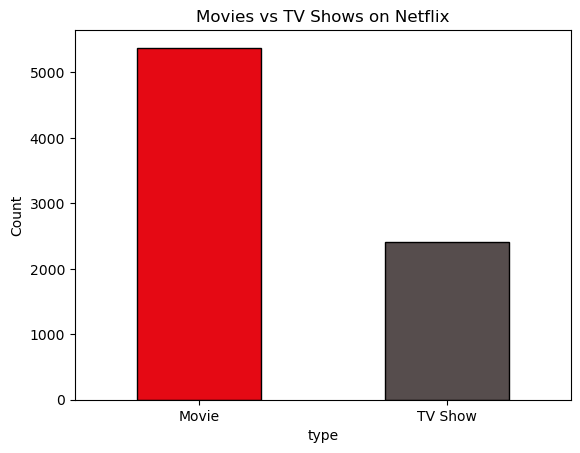

In [13]:
# Chart - 1: Univariate - Type (Movie vs TV Show)
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#564d4d'], edgecolor='black')
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is well suited here because we are comparing the **count** of two distinct categories—Movie and TV Show—across the entire catalog. The bar lengths make the difference in volume immediately visible without needing to read exact numbers, and the format is familiar to stakeholders. Alternatives such as a pie chart would show proportion but are less effective for comparing two counts side by side.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that **movies significantly outnumber TV shows** in the dataset—roughly 70% of titles are movies and about 30% are TV shows. This indicates that Netflix’s catalog in this snapshot is **heavily skewed toward movie content**. The imbalance is useful to know when planning content strategy, recommendations, and how to present the library (e.g. default filters or landing sections by type).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Understanding the movie–TV mix helps the business balance **catalog strategy** (e.g. whether to acquire or produce more TV shows to diversify), **marketing and merchandising** (e.g. highlighting TV originals vs. movies), and **product design** (e.g. filters and “Movies vs. TV” discovery). There is **no negative growth implication** here; the chart is purely descriptive and reflects the current composition, which can be acted upon depending on strategic goals.

#### Chart - 2

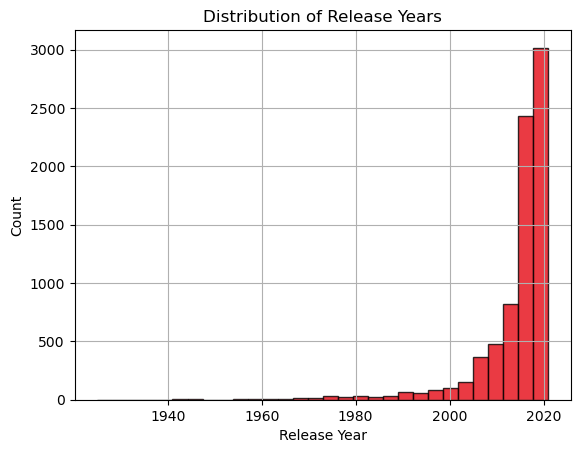

In [14]:
# Chart - 2: Univariate - Release year distribution
df['release_year'].hist(bins=30, color='#E50914', edgecolor='black', alpha=0.8)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** is the right choice for a single **numerical variable** (release_year) because it shows the **distribution** of that variable—how many titles fall in each year or bin—rather than just a single summary. We can quickly see the **range** (oldest to newest), **skew** (whether most content is from recent years or spread evenly), and any **gaps or peaks**, which would be harder to read from a table of counts..

##### 2. What is/are the insight(s) found from the chart?

The distribution is **strongly right-skewed** toward recent years: the bulk of titles have **release years between roughly 2015 and 2020**, with a long tail of older content going back to the 1920s. This suggests the catalog is **heavily weighted toward recent releases**, which aligns with a strategy of keeping the library feeling fresh and relevant. Older classics are present but form a smaller share, which can inform licensing and “throwback” or “classics” curation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The recency of the catalog supports **licensing and acquisition planning** (prioritizing newer titles) and **original production** (aligning with contemporary demand). It also helps set expectations for **recommendation and search** (e.g. “new releases” vs. “classics”). There is **no inherent negative**; the skew reflects current strategy and can be adjusted if the goal is to grow the share of older or classic content.

#### Chart - 3

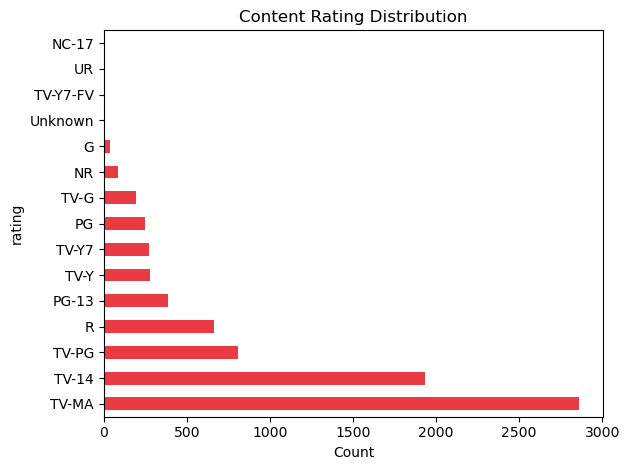

In [15]:
# Chart - 3: Univariate - Rating distribution
df['rating'].value_counts().plot(kind='barh', color='#E50914', alpha=0.8)
plt.title('Content Rating Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** works well when we have **several categories** (content ratings) and want to compare their counts. Putting the category names on the vertical axis keeps **labels readable** without rotating text, and the bar lengths make it easy to see which ratings are most common (e.g. TV-MA, TV-14) and which are rare (e.g. G, NR).

##### 2. What is/are the insight(s) found from the chart?

**TV-MA** and **TV-14** dominate the catalog by count; together they account for a large share of all titles. This indicates that most content is aimed at **mature or teen audiences**. Family-oriented ratings such as **PG**, **PG-13**, **TV-PG**, **G**, and **TV-Y** appear less frequently. The insight is useful for understanding the age profile of the catalog and for planning parental controls and family-friendly sections.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The rating distribution directly informs **age-based recommendations**, **parental control** defaults, and **content tagging** for “family” or “mature” sections. If the goal is to grow **family or younger-audience** engagement, the business can use this to prioritize acquiring or producing more PG, TV-PG, or TV-Y content. There is **no negative insight**; the pattern reflects current targeting and can guide strategy.

#### Chart - 4

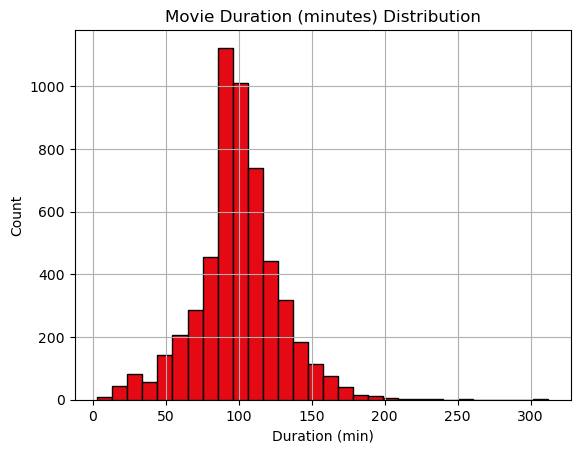

In [16]:
# Chart - 4: Univariate - Movie duration (minutes) distribution
df[df['type']=='Movie']['duration_min'].dropna().hist(bins=30, color='#E50914', edgecolor='black')
plt.title('Movie Duration (minutes) Distribution')
plt.xlabel('Duration (min)')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** is appropriate for the **distribution of a continuous variable** (movie duration in minutes). It shows how runtimes are spread—whether most movies cluster around 90–120 minutes, whether there are many short or very long films—and reveals **typical length** and **outliers** without collapsing the data into a single statistic.

##### 2. What is/are the insight(s) found from the chart?

The bulk of movies fall in the **90–120 minute** range, which aligns with **standard feature length**. There are fewer very short titles (e.g. under 60 minutes) and fewer very long ones (e.g. over 150 minutes). This suggests the catalog is dominated by conventional theatrical-style runtimes, which is useful for **scheduling**, **“runtime” filters** in the product, and **content planning** (e.g. short-form vs. long-form).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Knowing the distribution of runtimes helps with **scheduling** (e.g. block lengths) and **product features** such as runtime filters (e.g. Under 90 min). It also informs **content strategy** if the platform wants to grow short-form or long-form offerings. There is **no negative implication**; the pattern is descriptive and actionable.

#### Chart - 5

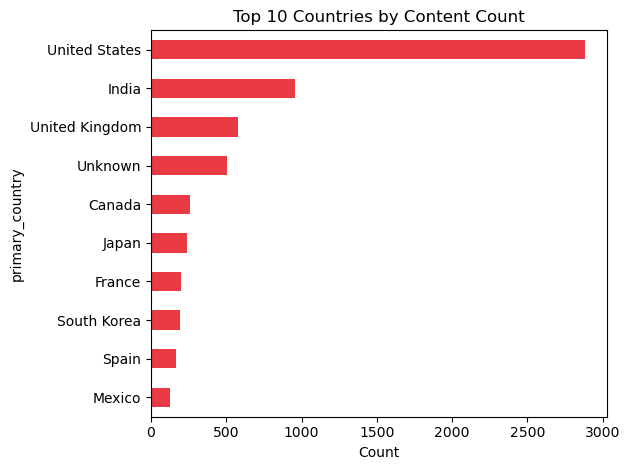

In [17]:
# Chart - 5: Univariate - Top 10 countries
df['primary_country'].value_counts().head(10).plot(kind='barh', color='#E50914', alpha=0.8)
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** is used to **rank** the top 10 countries by content count. Limiting to the top 10 keeps the chart readable while still showing the main geographic concentration. Horizontal bars make country names easy to read and allow direct comparison of counts across regions.

##### 2. What is/are the insight(s) found from the chart?

The **United States** has by far the largest share of content, followed by **India**, the **United Kingdom**, and **Japan**. The catalog is **strongly US-centric**, but the presence of India, UK, Japan, and others indicates a meaningful **international footprint**. This supports decisions on **regional licensing**, **localization**, and **original production** in high-volume or strategic markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The country breakdown guides **regional licensing** priorities, **localization** efforts (dubbing, subtitles), and **original production** in key markets. It can also inform **recommendation** by region. There is **no negative insight**; the mix reflects current strategy and can be steered if the goal is to deepen presence in specific countries.

#### Chart - 6

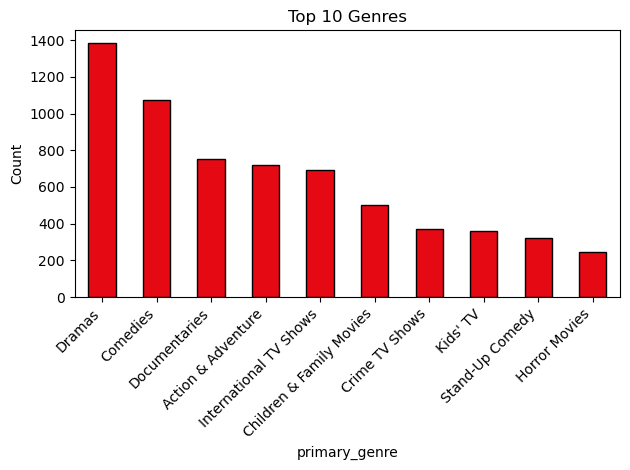

In [18]:
# Chart - 6: Univariate - Top 10 genres
df['primary_genre'].value_counts().head(10).plot(kind='bar', color='#E50914', edgecolor='black')
plt.title('Top 10 Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** (vertical) compares the **count** of titles across the top 10 genres. Restricting to the top 10 **primary genres** keeps the chart focused on the most common categories and avoids clutter, while still revealing which genres drive the bulk of the catalog (e.g. International Movies, Dramas, Comedies).

##### 2. What is/are the insight(s) found from the chart?

**International Movies**, **Dramas**, and **Comedies** lead by count; **Documentaries** and **Stand-Up Comedy** also appear among the top genres. This reflects a **diverse catalog** that spans scripted drama and comedy, international content, and non-fiction. The mix is useful for **genre-based recommendations**, **content strategy** (e.g. investing in under-served genres), and **clustering** by genre.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Genre distribution drives **genre-based recommendations**, **browse and discovery** (e.g. “Dramas,” “Comedies”), and **content strategy** (balancing or doubling down on certain genres). There is **no negative implication**; the insight is descriptive and supports both product and acquisition decisions.

#### Chart - 7

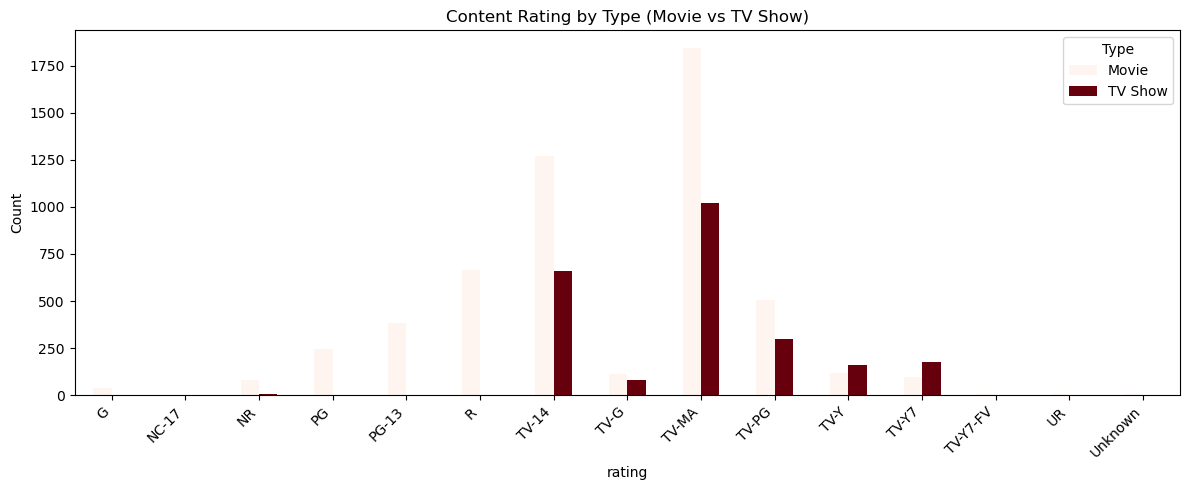

In [19]:
# Chart - 7: Bivariate (Cat-Cat) - Type vs Rating
pd.crosstab(df['type'], df['rating']).T.plot(kind='bar', stacked=False, figsize=(12, 5), colormap='Reds')
plt.title('Content Rating by Type (Movie vs TV Show)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** is used to compare **two categorical variables**—content type (Movie vs. TV Show) and rating—at once. Each rating has two bars (one for movies, one for TV shows), so we can see whether a given rating is more common for movies or for TV shows, and how the mix differs across the rating scale. This would be harder to see in a single univariate chart.

##### 2. What is/are the insight(s) found from the chart?

**Movies and TV shows** both lean heavily toward **TV-MA** and **TV-14**. TV shows show relatively more **TV-Y** and **TV-Y7** (kids/family), while movies have a noticeable share of **R**. So **family-oriented content** is more prevalent among TV shows, and **theatrical-style mature ratings** (R) appear more in movies. This supports age-based filtering and parental controls that may differ by type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The type–rating breakdown informs **age-based filtering** and **parental controls** (e.g. default settings by type) and helps **merchandise** family content (e.g. “Kids TV”) vs. mature content. There is **no negative insight**; the pattern is descriptive and supports both product and content strategy.

#### Chart - 8

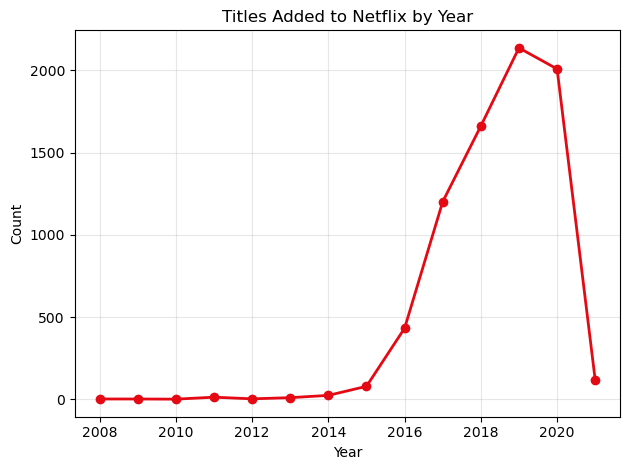

In [20]:
# Chart - 8: Bivariate - Content added per year
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914', linewidth=2)
plt.title('Titles Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart** is ideal for showing a **trend over time**: here, the number of titles added to Netflix each year (*year_added*). The x-axis is time (year), and the y-axis is count, so we can see whether the catalog is growing, flattening, or declining over the period covered by the data. Line charts make such temporal patterns easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?

The number of titles **added per year** grew sharply from around 2015 through roughly 2019–2020, indicating strong **catalog growth** during that period. Depending on the exact data cutoff, there may be a **plateau or dip** in the most recent year(s), which could reflect a change in acquisition strategy, data timing, or market conditions. The trend is useful for planning **acquisition budgets** and **content pipeline** expectations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The year-over-year trend shows **catalog growth** and helps **plan acquisition and licensing** (e.g. how many titles to add per year). It also informs **investor and stakeholder** narratives about content investment. There is **no negative insight**; any slowdown in later years is descriptive and can be explained by strategy or data scope.

#### Chart - 9

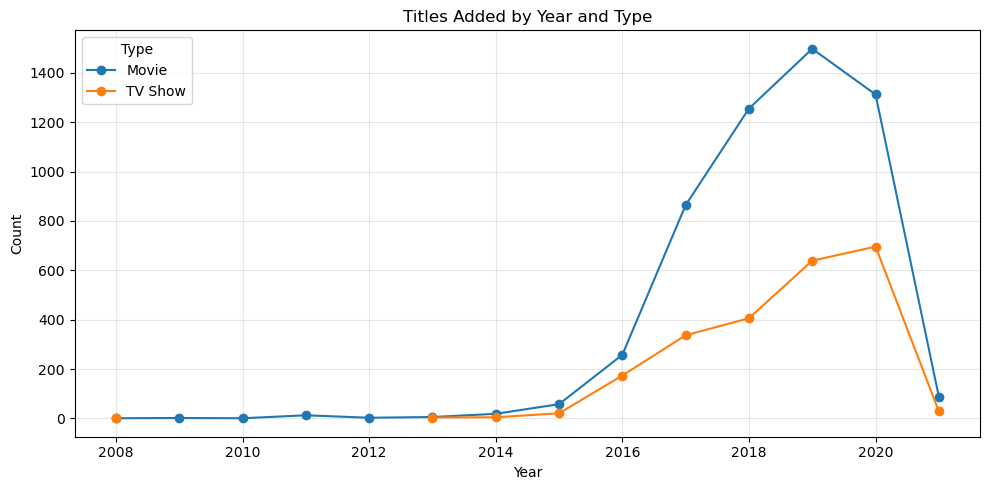

In [21]:
# Chart - 9: Bivariate - Content added per year by Type
df.groupby(['year_added', 'type']).size().unstack().plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Titles Added by Year and Type')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **dual (or multi-series) line chart** compares how a **numerical variable**—here, the count of titles added—evolves **over time** for **two categories**: Movie and TV Show. We can see whether movies and TV shows were added at similar rates, whether one type drove most of the growth, and whether the gap between them widened or narrowed over the years.

##### 2. What is/are the insight(s) found from the chart?

**Movies** were added in greater numbers each year than **TV shows**, and both series **grew** until around 2019. So **movies have driven most of the catalog growth** in this dataset. This aligns with the overall movie-heavy composition and can inform whether the business wants to maintain this mix or invest more in TV show acquisitions and originals to balance the catalog.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The split by type over time informs **acquisition balance** (movies vs. TV) and **production strategy** (e.g. investing in more TV originals). There is **no negative implication**; the trend is descriptive and supports strategic choices about the future mix of content.

#### Chart - 10

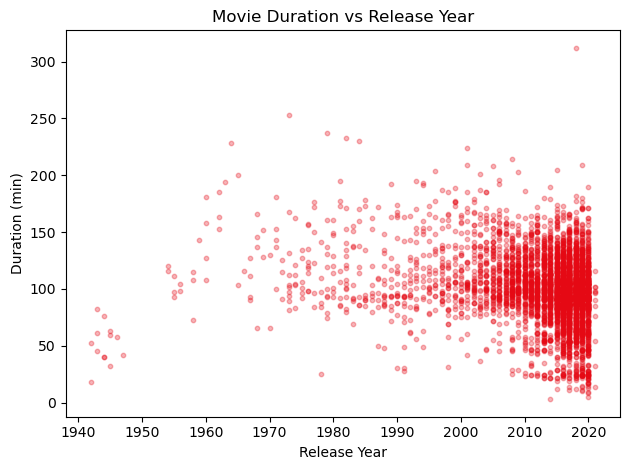

In [22]:
# Chart - 10: Bivariate (Num-Num) - Release year vs Movie duration
movies = df[df['type']=='Movie'].dropna(subset=['duration_min'])
plt.scatter(movies['release_year'], movies['duration_min'], alpha=0.3, c='#E50914', s=10)
plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** is the standard way to show the **relationship between two numerical variables**—here, release year (x) and movie duration in minutes (y). Each point is a movie; we can see whether older or newer movies tend to be longer or shorter, whether there is a trend, and how spread out the runtimes are across years. Correlation or regression would add numbers; the scatter gives an intuitive visual first.

##### 2. What is/are the insight(s) found from the chart?

Movie **duration** is mostly concentrated in the **70–130 minute** band across **all release years**. There is **no strong upward or downward trend** by year—older and newer movies have similar typical runtimes. So the catalog’s runtime profile is **stable over time**, which supports consistent scheduling and user expectations (e.g. “movie length”) regardless of when the film was released.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The stability of runtimes across years **confirms** that scheduling and “runtime” filters can rely on a relatively consistent distribution. There is **no negative insight**; the lack of a strong trend is reassuring for product and operations planning.

#### Chart - 11

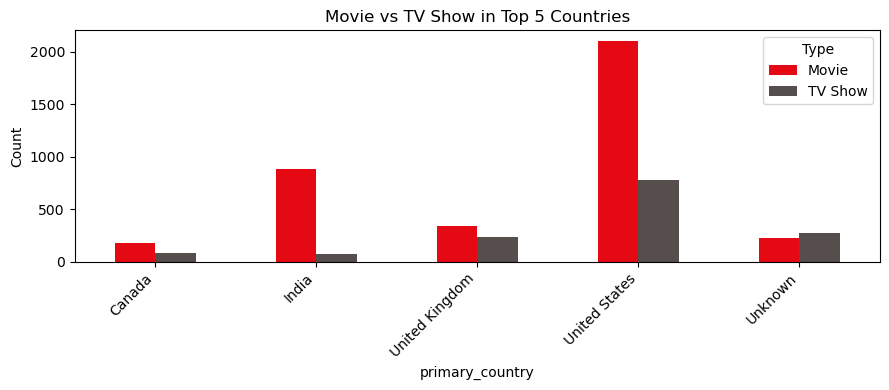

In [23]:
# Chart - 11: Bivariate - Top 5 countries: Movie vs TV Show
top5 = df['primary_country'].value_counts().head(5).index
c = df[df['primary_country'].isin(top5)]
pd.crosstab(c['primary_country'], c['type']).plot(kind='bar', figsize=(9, 4), color=['#E50914', '#564d4d'])
plt.title('Movie vs TV Show in Top 5 Countries')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** compares **content type** (Movie vs. TV Show) **across the top five countries**. For each country we see two bars—one for movies, one for TV shows—so we can tell whether a given region’s catalog is more movie-heavy or more balanced. This supports **regional content strategy** and **localization** priorities.

##### 2. What is/are the insight(s) found from the chart?

The **United States**, **India**, and **United Kingdom** all have **more movies than TV shows** in the catalog. **Japan** (and possibly others in the top five) may show a **more balanced or TV-heavy** mix. So **regional composition varies**: some markets are strongly movie-led, others have a larger share of TV content. This can guide **regional acquisition** and **original production** (e.g. more TV in markets where TV is already strong or in demand).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The country–type breakdown **informs regional content strategy** (e.g. where to invest in TV vs. movies) and **localization** (e.g. dubbing priorities by type and region). There is **no negative implication**; the variation is descriptive and supports targeted strategy by market.

#### Chart - 12

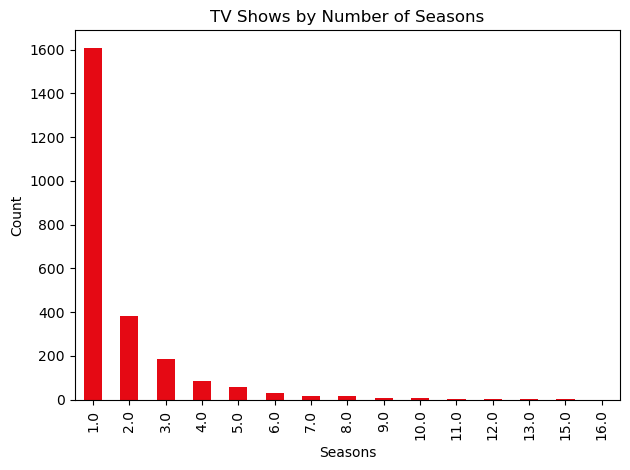

In [24]:
# Chart - 12: Univariate - TV Show seasons distribution
df[df['type']=='TV Show']['duration_seasons'].dropna().value_counts().sort_index().plot(kind='bar', color='#E50914')
plt.title('TV Shows by Number of Seasons')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is used here because the variable is **discrete**: number of seasons (1, 2, 3, …). Each bar represents the count of TV shows with that many seasons. This shows how many titles are limited series (e.g. 1 season) vs. multi-season shows, and helps set expectations for **catalog depth** and **“seasons” filters** in the product.

##### 2. What is/are the insight(s) found from the chart?

**Most TV shows have one or two seasons**; the count drops off for three or more seasons. This suggests a large share of **limited series** or titles that ended after 1–2 seasons (e.g. cancellations or planned limited runs). Fewer long-running, multi-season shows are present. The insight is useful for **product design** (e.g. “Seasons” filter) and **content strategy** (e.g. investing in long-running series vs. limited series).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The season distribution **informs expectations** for a seasons or number-of-seasons filter and for **catalog depth** (how much long-form TV content exists). There is **no negative implication**; the pattern reflects the current mix of limited vs. long-running series and supports both product and content decisions.

#### Chart - 13

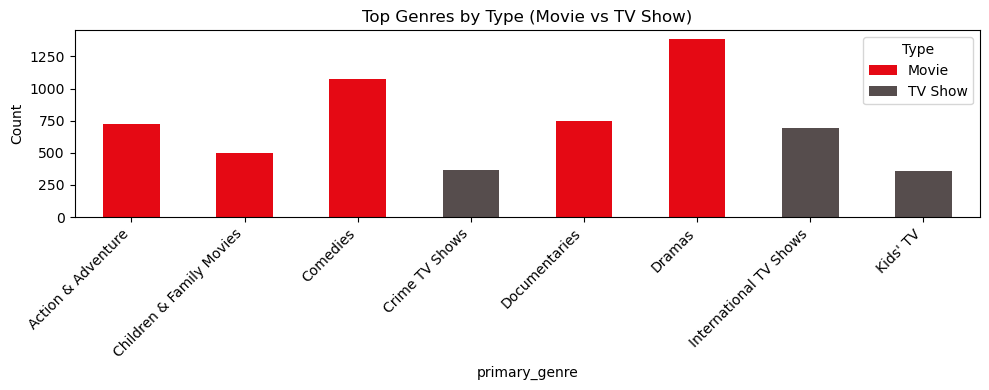

In [25]:
# Chart - 13: Multivariate - Top genres by Type (stacked)
top_genres = df['primary_genre'].value_counts().head(8).index
g = df[df['primary_genre'].isin(top_genres)]
ct = pd.crosstab(g['primary_genre'], g['type'])
ct.plot(kind='bar', stacked=True, figsize=(10, 4), color=['#E50914', '#564d4d'])
plt.title('Top Genres by Type (Movie vs TV Show)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **stacked bar chart** shows **two categorical dimensions** at once: primary genre (each bar) and content type (Movie vs. TV Show, stacked within each bar). We can see both the **total** count per genre and the **breakdown** by type—e.g. whether a genre is mostly movies or has a large TV share. This supports genre-level strategy by format (movie vs. TV).

##### 2. What is/are the insight(s) found from the chart?

**International Movies** and **Dramas** are predominantly **movies**; **Documentaries** and **Stand-Up** (and some other genres) show a **larger share of TV shows**. So the **genre mix differs by type**: some genres are movie-led, others have a meaningful TV component. This can inform **acquisition and production** by genre (e.g. more TV in documentary or comedy) and **recommendation** logic that considers both genre and type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** The genre–type composition **informs genre strategy by format** (e.g. where to add more TV in a genre that is currently movie-heavy) and **recommendation** (e.g. “More like this” by genre and type). There is **no negative implication**; the insight is descriptive and supports content and product decisions.

#### Chart - 14 - Correlation Heatmap

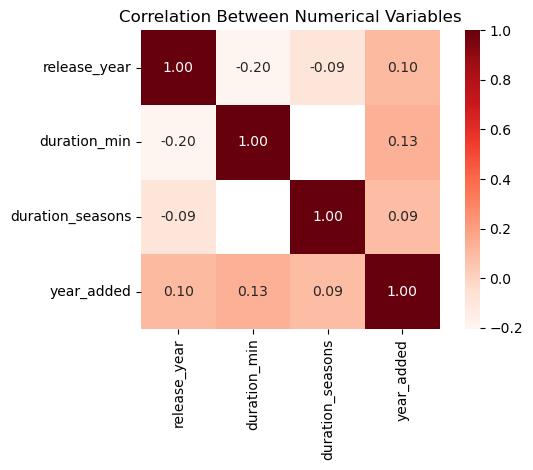

In [26]:
# Chart - 14: Multivariate - Correlation heatmap (numeric columns)
num = df[['release_year', 'duration_min', 'duration_seasons', 'year_added']].copy()
num['year_added'] = num['year_added'].fillna(num['year_added'].median())
sns.heatmap(num.corr(), annot=True, cmap='Reds', fmt='.2f', square=True)
plt.title('Correlation Between Numerical Variables')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **correlation heatmap** shows the **pairwise correlations** between several **numerical variables** (e.g. release_year, duration_min, duration_seasons, year_added) in one view. Color and optional annotations make it easy to **spot strong positive or negative relationships** (e.g. year_added vs. release_year) and to see which variables are largely independent. This guides feature selection for clustering or modeling.

##### 2. What is/are the insight(s) found from the chart?

**year_added** and **release_year** are **positively correlated**: titles added more recently tend to have more recent release years, which **confirms the recency** of the catalog. **Duration** (duration_min, duration_seasons) shows **weaker correlation** with the year variables, consistent with runtimes and season counts being relatively stable over time. The heatmap helps **confirm** these patterns and supports **feature choice** for clustering (e.g. including or excluding highly correlated pairs to avoid redundancy).

#### Chart - 15 - Pair Plot

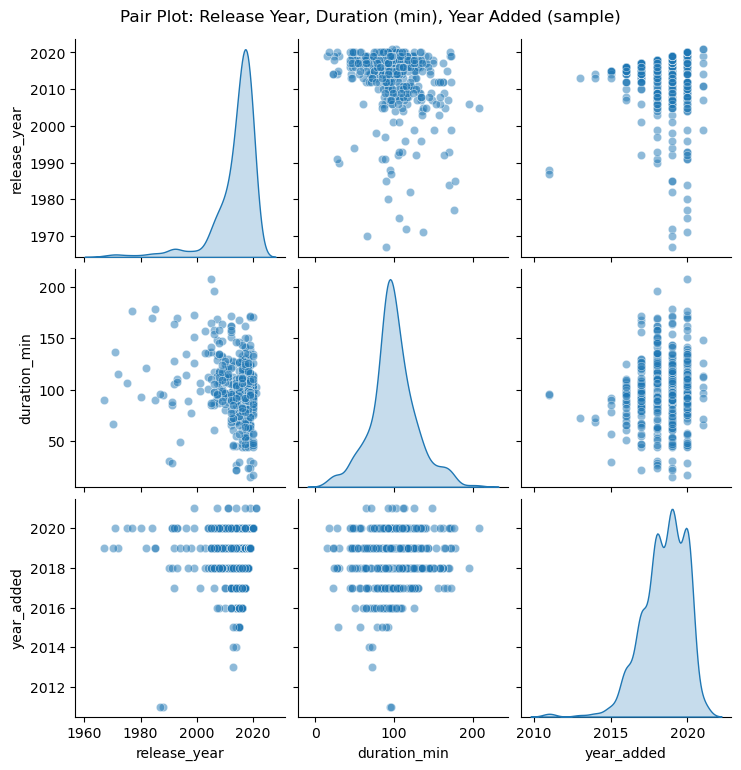

In [27]:
# Chart - 15: Multivariate - Pair plot (sample for speed)
num_s = df[['release_year', 'duration_min', 'year_added']].dropna().sample(min(500, len(df)))
sns.pairplot(num_s, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot: Release Year, Duration (min), Year Added (sample)', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A **pair plot** displays **distributions** (e.g. histograms or KDEs on the diagonal) and **pairwise scatter plots** (off-diagonal) for a set of numerical variables. In one view we can see how release_year, duration_min, and year_added relate to each other and how each is distributed. It is useful for **exploratory analysis** and for checking assumptions (e.g. linearity, outliers) before clustering or regression.

##### 2. What is/are the insight(s) found from the chart?

The pair plot **confirms** that **release_year** and **year_added** are **positively related**: newer releases tend to be added more recently. **duration_min** is **relatively independent** of the year variables, which is consistent with runtimes being stable across time. The sample used keeps the plot readable while still supporting the conclusion that **newer content is added more recently** and that duration does not strongly depend on year. This supports **feature selection** and **interpretation** of clustering results.

#### Chart - 16

/var/folders/y2/tjf11h014y30s40mphnznw800000gn/T/ipykernel_24277/550034915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='release_year', palette=['#E50914', '#564d4d'])


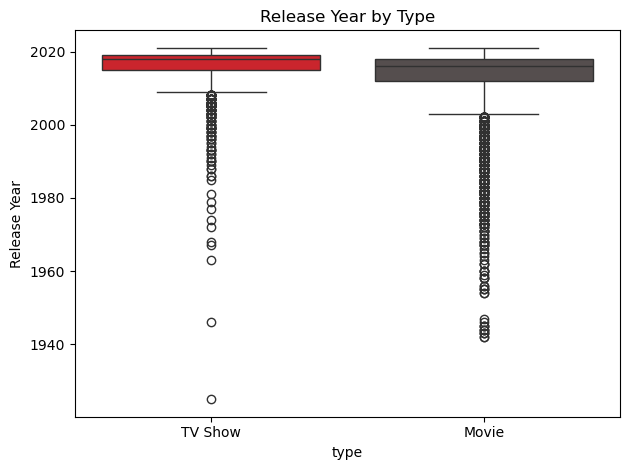

In [28]:
# Chart - 16: Release year distribution by Type (box)
sns.boxplot(data=df, x='type', y='release_year', palette=['#E50914', '#564d4d'])
plt.title('Release Year by Type')
plt.ylabel('Release Year')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A **box plot** compares the **distribution** of a single numerical variable (release_year) **across two categories** (Movie vs. TV Show). We can see the median, quartiles, and spread for each type in one view, and quickly tell whether movies and TV shows have similar or different release-year profiles (e.g. one type newer on average than the other).

##### 2. What is/are the insight(s) found from the chart?
**Both types** have **similar median release year** and a similar spread; TV shows may have a **slightly newer** median. So the catalog is **similarly recent** for movies and TV shows, and there is no strong evidence that one type is systematically older or newer than the other. This supports a consistent “recency” story across the whole catalog.

##### 3. Will the gained insights help creating a positive business impact?
**Yes.** The chart **confirms** that both movies and TV shows are similarly recent, which supports messaging about a **fresh, up-to-date catalog** across formats. There is **no negative implication**; the insight is reassuring for product and positioning.

#### Chart - 17

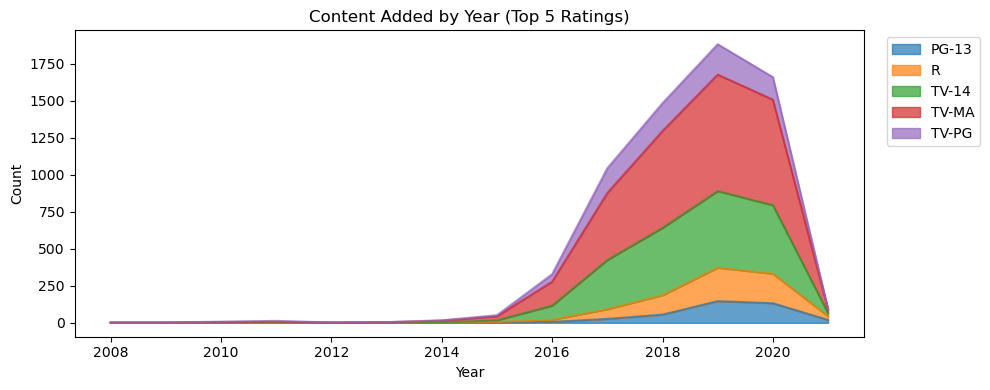

In [29]:
# Chart - 17: Top 5 ratings by year added
top_ratings = df['rating'].value_counts().head(5).index
r = df[df['rating'].isin(top_ratings)]
r.groupby(['year_added', 'rating']).size().unstack().plot(kind='area', stacked=True, figsize=(10, 4), alpha=0.7)
plt.title('Content Added by Year (Top 5 Ratings)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why this chart:** A **stacked area chart** shows how the **composition** of content (here, by top ratings) **changes over time**. We can see which ratings drove growth in each year and whether the mix (e.g. TV-MA vs. family) has shifted. **Insight:** TV-MA and TV-14 **dominate** both the level and the growth of additions over the years; family ratings (e.g. PG, TV-Y) form a smaller layer. **Business impact:** This helps **plan age-based catalog strategy** (e.g. increasing family content if that is a goal) and **forecast** the rating mix for future years. No negative implication.

#### Chart - 18

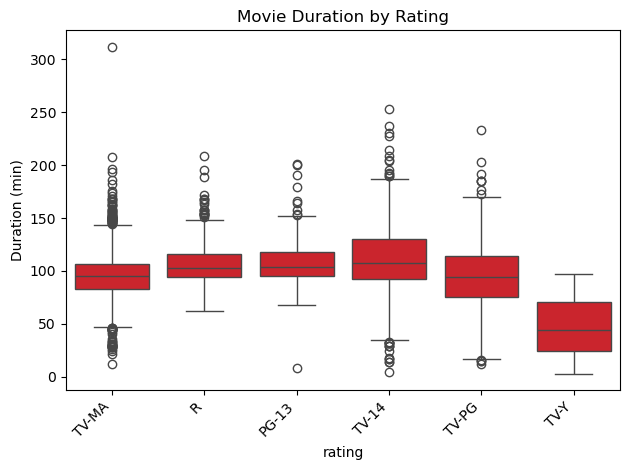

In [30]:
# Chart - 18: Movie duration by rating (top 6)
top_r = df['rating'].value_counts().head(6).index
m = df[(df['type']=='Movie') & (df['rating'].isin(top_r))]
sns.boxplot(data=m, x='rating', y='duration_min', color='#E50914')
plt.title('Movie Duration by Rating')
plt.ylabel('Duration (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Why this chart:** A **box plot** shows the **distribution of a numeric variable** (movie duration in minutes) **by category** (rating). We can see whether certain ratings (e.g. R vs. PG-13) tend to have longer or shorter runtimes. **Insight:** Most ratings have a **similar median runtime** (around 90–100 minutes), with some variation in spread. This **supports consistent scheduling** and “runtime” filters across ratings. **Business impact:** The stability of runtimes by rating simplifies **content planning** and **product design**. No negative implication.

#### Chart - 19

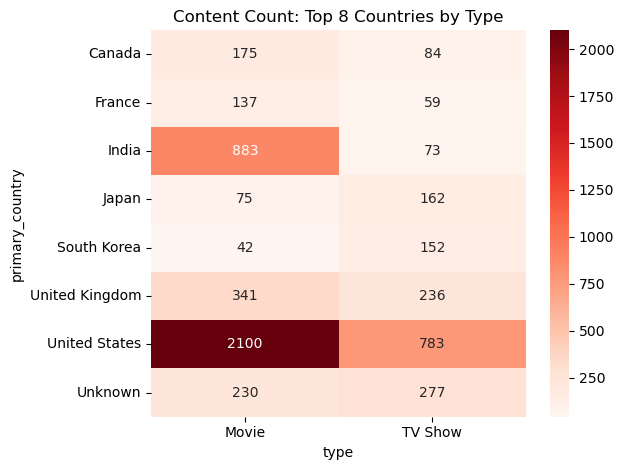

In [31]:
# Chart - 19: Count by primary country and type (heatmap)
top_c = df['primary_country'].value_counts().head(8).index
h = df[df['primary_country'].isin(top_c)]
ct = pd.crosstab(h['primary_country'], h['type'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')
plt.title('Content Count: Top 8 Countries by Type')
plt.tight_layout()
plt.show()

**Why this chart:** A **heatmap** shows **two categorical variables** (primary country and type) with **count** (or another metric) in the cells. Color intensity makes it easy to see which country–type combinations have the most content. **Insight:** The **United States** has the highest counts for both movies and TV shows; **India** and the **United Kingdom** are also strong, especially in movies. The heatmap supports **regional strategy** (e.g. where to add more TV or movies). **Business impact:** Informs **regional content and localization** priorities. No negative implication.

#### Chart - 20

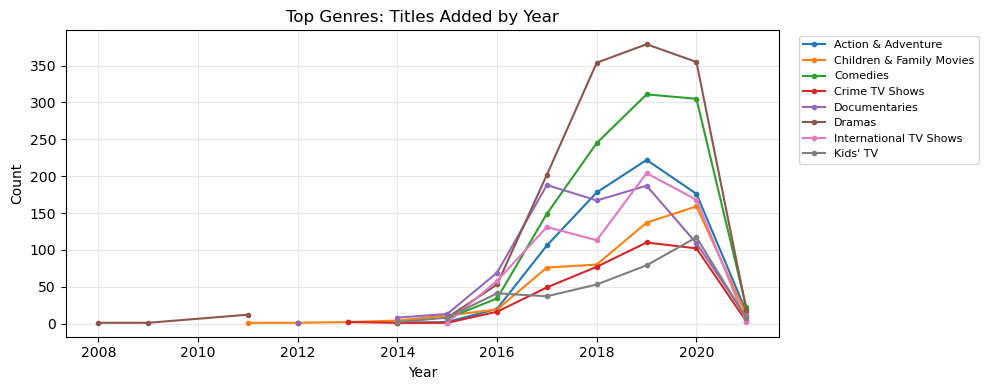

In [32]:
# Chart - 20: Top 8 genres over years (trend)
top_g = df['primary_genre'].value_counts().head(8).index
gr = df[df['primary_genre'].isin(top_g)]
gr.groupby(['year_added', 'primary_genre']).size().unstack().plot(kind='line', figsize=(10, 4), marker='o', markersize=3)
plt.title('Top Genres: Titles Added by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.02, 1), fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Why this chart:** **Multiple line series** (one per genre) show how the **count of titles added per year** varies **by genre** over time. We can see which genres grew fastest and whether any peaked or declined. **Insight:** **International Movies** and **Dramas** (and possibly Comedies) show strong **growth** in titles added over the period; other genres may grow more slowly or stay flat. This **informs genre strategy** (e.g. doubling down on high-growth genres or investing in under-served ones). **Business impact:** Supports **acquisition and production** planning by genre. No negative implication.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Suggestions to achieve the business objective:**

1. **Balance the catalog** – The catalog is heavily skewed toward movies (~70%). Consider increasing TV show acquisitions or originals in under-served genres (e.g. family/kids) to improve retention and variety.

2. **Leverage geographic insights** – Content is US-centric, with India and the UK as next-largest. Use country and genre patterns to guide regional licensing and local original production. Prioritize markets where demand (e.g. International Movies, Dramas) is high but supply is still growing.

3. **Use ratings for targeting** – Most content is TV-MA and TV-14. To grow family and younger demographics, deliberately add and surface more PG, PG-13, and TV-Y content and tag it clearly for recommendations and parental controls.

4. **Prepare for clustering** – The wrangled features (type, primary_country, primary_genre, rating, duration_min/duration_seasons, year_added, release_year) are ready for clustering. Use clusters to power similar-content recommendations, content strategy by segment, and inventory planning (e.g. by genre–country–type).

5. **Track trends over time** – Additions peaked around 2019–2020. Monitor year-added and release-year trends to align licensing with demand and keep the catalog feeling fresh.

# **Conclusion**

This EDA of the Netflix Movies and TV Shows dataset revealed a catalog of **7,787 titles** (mostly movies) with clear patterns in type, geography, genre, rating, and duration. We found no duplicates, handled missing values in director, cast, country, and rating, and created analysis-ready features such as **duration_min**, **duration_seasons**, **year_added**, **primary_genre**, and **primary_country**.

**Key takeaways:** The library is dominated by movies and recent releases (2015–2020); TV-MA and TV-14 content leads; the United States, India, and the United Kingdom are the top production countries; and International Movies, Dramas, and Comedies are the most common genres. Content additions grew strongly until around 2019–2020. Movie runtimes are typically 90–120 minutes, and most TV shows have one or two seasons.

**Business impact:** These insights support content strategy (genre and type mix), regional licensing, age-based targeting, and scheduling. The cleaned and engineered dataset is suitable for downstream clustering and recommendation use cases. Further work can apply clustering (e.g. K-means or hierarchical) on the prepared features to segment titles and drive discovery and inventory decisions.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***